In [1]:
%cd ..

/Users/kiwifern/Development/airfoil-completion


/Users/kiwifern/Development/airfoil-completion/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import argparse
import datetime
import json
import os
import sys
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

import config
from config import (
    DIFFUSION_PARAMS,
    EXECUTION_NAME,
    GUIDANCE_SCALE,
    MODEL_NAME,
    WEIGHT_PATH,
)
from src.data import AirfoilDataset
from src.diffusion_blend_mask import RePaintDiffuser
from src.models.model_registry import MODEL_REGISTRY
from src.xfoil_utils import get_xf_instance  # 共有インスタンスで高速化

In [4]:
def get_cl_cd(coord: np.ndarray, angle: float = 5.0) -> Tuple[float, float]:
    try:
        import numpy as _np
        from xfoil.model import Airfoil as _Airfoil

        xf = get_xf_instance()
        xf.Re = 3e6
        xf.max_iter = 100
        x, y = coord.reshape(2, -1)
        xf.airfoil = _Airfoil(x=x, y=y)
        c = xf.a(angle)
        if c is None or len(c) < 2:
            return (np.nan, np.nan)
        return (float(_np.round(c[0], 10)), float(_np.round(c[1], 10)))
    except Exception:
        return (np.nan, np.nan)

In [8]:
def plot_cl_cd_from_paths(
    paths: List[str],
    angle_deg: float,
    base_point: Optional[Tuple[float, float]] = None,
    target_cl_line: Optional[float] = None,  # ADDED: オレンジ点線
    cl_plus_line: Optional[float] = None,  # ADDED: 赤点線
):
    """
    paths の各要素:
      - .npz: 'cls','cds' を読み込んで散布（XFoil無し）
      - .npy: 形状から XFoil で CL/CD を計算（遅い）
    base_point を与えると、その1点を大きいマーカーで重ね描き。
    """
    cmap = plt.get_cmap("tab10")
    plt.figure(figsize=(8, 6))
    for i, p in enumerate(paths):
        if p.endswith(".npz"):
            cache = np.load(p)
            cls = cache["cls"]
            cds = cache["cds"]
        else:
            arr = np.load(p, allow_pickle=True)
            if arr.ndim == 2:
                arr = arr.reshape(1, *arr.shape)
            cls, cds = [], []
            for k in tqdm(range(arr.shape[0])):
                cl, cd = get_cl_cd(arr[k], angle=angle_deg)
                if not (np.isnan(cl) or np.isnan(cd)):
                    cls.append(cl)
                    cds.append(cd)
            cls = np.array(cls)
            cds = np.array(cds)
        if len(cls) > 0:
            plt.scatter(cls, cds, alpha=0.6, c=[cmap(i % 10)])

    # ADDED: 縦線（指定CL: オレンジ点線, 指定CL+シフト: 赤点線）
    if target_cl_line is not None:
        plt.axvline(target_cl_line, color="orange", linestyle="--", linewidth=2, label="base CL")
    if cl_plus_line is not None:
        plt.axvline(cl_plus_line, color="red", linestyle="--", linewidth=2, label="target CL")

    # 基準点の重ね描き
    if base_point is not None and not (np.isnan(base_point[0]) or np.isnan(base_point[1])):
        plt.scatter(
            [base_point[0]],
            [base_point[1]],
            s=150,
            marker="*",
            edgecolors="k",
            linewidths=1.0,
            c="blue",
        )  # CHANGED

    plt.xlabel("CL")
    plt.ylabel("CD")
    plt.title("CL–CD Scatter")
    plt.grid(True)

    # plt.legend()
    plt.tight_layout()
    # plt.savefig(out_path, dpi=200)
    plt.show()

In [9]:
train_subset_npz = "./results/250506-001:ResUnet(3-layer)+CFG(all-zero)+pos-enc+beta_end0.05/analysis/251127121612_N100_R10_J10_M:tail_MPR:0.5_BR:0.1_linear_1.0_SHIFT:0.1_CLIN:1.2/251127121612_N100_R10_J10_M:tail_MPR:0.5_BR:0.1_linear_1.0_SHIFT:0.1_CLIN:1.2_train_clcd_subset.npz"

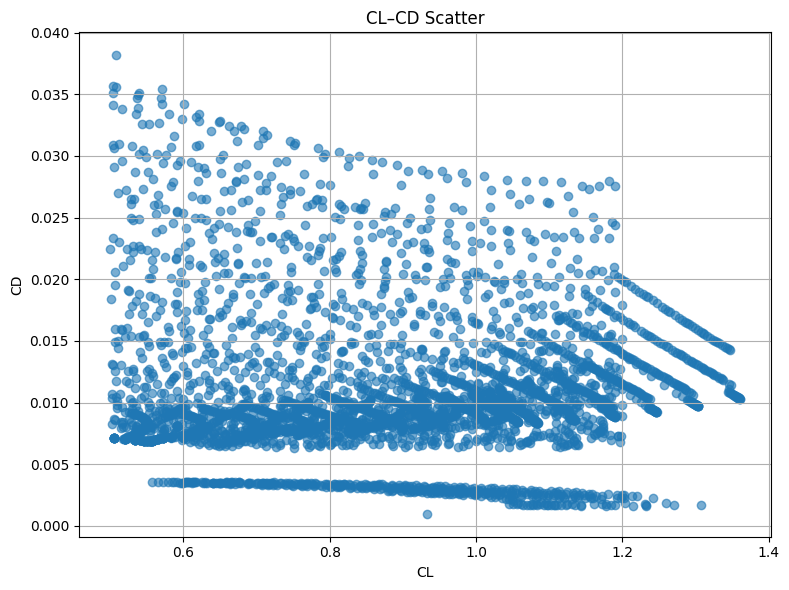

In [10]:
plot_cl_cd_from_paths(
    paths = [train_subset_npz],
    angle_deg = 5.0,
    base_point = None,
    target_cl_line = None,  # ADDED: オレンジ点線
    cl_plus_line = None,  # ADDED: 赤点線
)

In [11]:
cache = np.load(train_subset_npz)
cls = cache["cls"]
cds = cache["cds"]

In [13]:
cls

array([0.565521  , 0.56037968, 0.55686647, ..., 0.63201529, 0.61508119,
       0.60682952], shape=(3767,))

AxisError: axis 1 is out of bounds for array of dimension 1

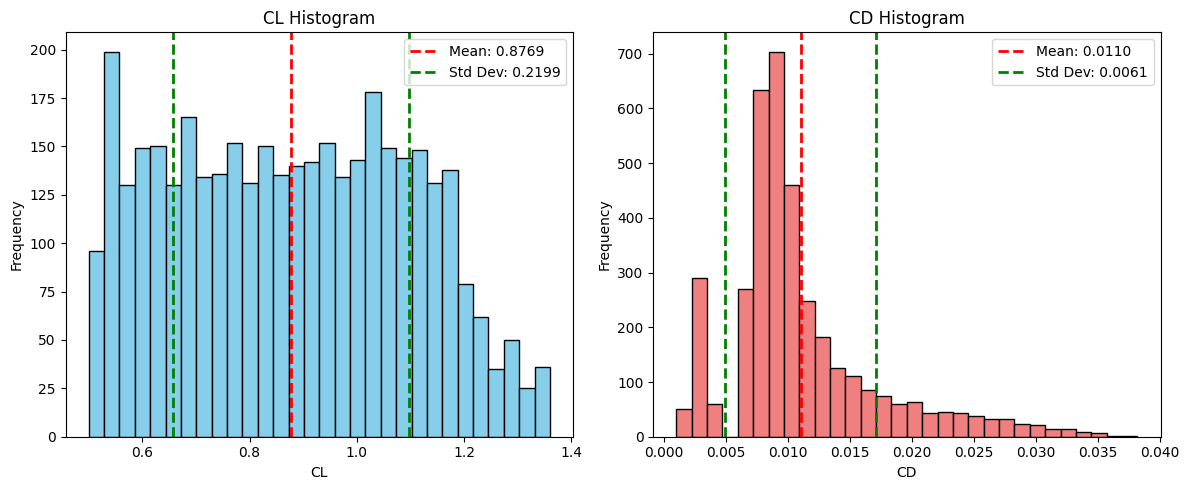

In [17]:
# cls/cdsのヒストグラムをそれぞれ表示して、統計値（平均・標準偏差）を表示する
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(cls, bins=30, color='skyblue', edgecolor='black')
plt.title('CL Histogram')
plt.xlabel('CL')
plt.ylabel('Frequency')
plt.axvline(np.nanmean(cls), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.nanmean(cls):.4f}')
plt.axvline(np.nanmean(cls) + np.nanstd(cls), color='green', linestyle='dashed', linewidth=2, label=f'Std Dev: {np.nanstd(cls):.4f}')
plt.axvline(np.nanmean(cls) - np.nanstd(cls), color='green', linestyle='dashed', linewidth=2)
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(cds, bins=30, color='lightcoral', edgecolor='black')  
plt.title('CD Histogram')
plt.xlabel('CD')
plt.ylabel('Frequency')
plt.axvline(np.nanmean(cds), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.nanmean(cds):.4f}')
plt.axvline(np.nanmean(cds) + np.nanstd(cds), color='green',linestyle='dashed', linewidth=2, label=f'Std Dev: {np.nanstd(cds):.4f}')
plt.axvline(np.nanmean(cds) - np.nanstd(cds), color='green', linestyle='dashed', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()